# ICE Task 2: Introduction to Linear Regression for Medical Aid Cost Prediction
**Module:** SMAA8411w – Statistical and Mathematical Analysis  
**Student Number:** ST10508304 

**Dataset:** Medical Insurance Cost Dataset  
**Target Variable:** `charges` (Medical Insurance Cost)

---

## Overview
In this notebook, we will:
1. Load and explore the Medical Insurance dataset
2. Conduct Exploratory Data Analysis (EDA)
3. Preprocess the data for modelling
4. Train a Linear Regression model
5. Evaluate the model's performance
6. Reflect on our findings

---

## Task 1: Import Required Libraries

Before we begin, we need to import the Python libraries that will support our analysis:

- **pandas**: For loading and manipulating tabular data (DataFrames)
- **numpy**: For numerical computations and array operations
- **matplotlib & seaborn**: For creating visualisations and plots
- **scikit-learn**: For machine learning tasks — splitting data, training models, and evaluating performance

These are the standard tools used in data science and machine learning workflows.

In [3]:
# Task 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for preprocessing, modelling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Display settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


---

## Task 2: Load and Explore the Dataset

### About the Dataset
The **Medical Insurance Cost Dataset** contains information about individuals and their associated health insurance charges. It is commonly used to explore the factors that influence the cost of medical insurance.

### Column Descriptions

| Feature | Type | Description |
|---------|------|-------------|
| `age` | Numeric | Age of the insured client (in years) |
| `sex` | Categorical | Gender of the client (`male` / `female`) |
| `bmi` | Numeric | Body Mass Index — a measure of body fat based on height and weight |
| `children` | Numeric | Number of dependents covered under the policy |
| `smoker` | Categorical | Whether the client is a smoker (`yes` / `no`) |
| `region` | Categorical | Geographic region of the client (`southwest`, `southeast`, `northwest`, `northeast`) |
| `charges` | Numeric | **Target variable** — the medical insurance cost billed to the client (in USD) |

Our goal is to **predict `charges`** based on the other features.

In [4]:
# Task 2: Load the Dataset
df = pd.read_csv('insurance.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: 1338 rows x 7 columns

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Check data types and column structure
print("Dataset Info:")
print("-" * 40)
df.info()

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# Check for missing values
print("Missing Values Per Column:")
print("-" * 30)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values Per Column:
------------------------------
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


In [7]:
# Summary statistics for numeric columns
print("Summary Statistics:")
df.describe().round(2)

Summary Statistics:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


### Observations from the Dataset

- **Number of records:** 1,338 rows and 7 columns
- **Data types:** The dataset contains a mix of numeric (`age`, `bmi`, `children`, `charges`) and categorical (`sex`, `smoker`, `region`) columns
- **Missing values:** There are **no missing values** in the dataset — it is clean and ready for analysis
- **Charges range:** Insurance charges range from ~R1,121 to ~R60,000+, indicating significant variability in costs
- **Age range:** Clients range from 18 to 64 years old
- **BMI range:** Values range from about 15 to 53 — a wide spectrum from underweight to severely obese

---

## Task 3: Exploratory Data Analysis (EDA)

EDA helps us understand the data visually before modelling. We will:
- Examine the **distribution of the target variable** (`charges`)
- Explore **relationships between features and charges**
- Identify which variables may be most important for prediction

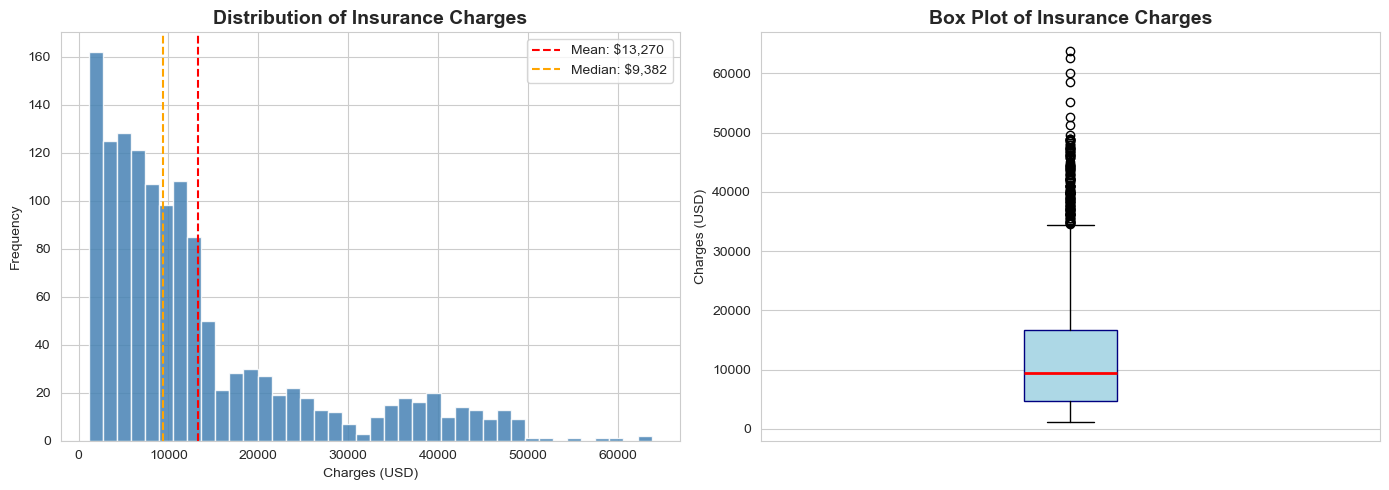

Figure saved.


In [8]:
# 3.1 Distribution of Insurance Charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
axes[0].axvline(df['charges'].median(), color='orange', linestyle='--', label=f'Median: ${df["charges"].median():,.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['charges'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot of Insurance Charges', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Charges (USD)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('charges_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved.")

**Interpretation:** The distribution of `charges` is **right-skewed**, meaning most clients pay relatively low premiums, but a smaller group pays very high amounts. The mean is pulled upward by these high-cost outliers, which is typical of health insurance data.

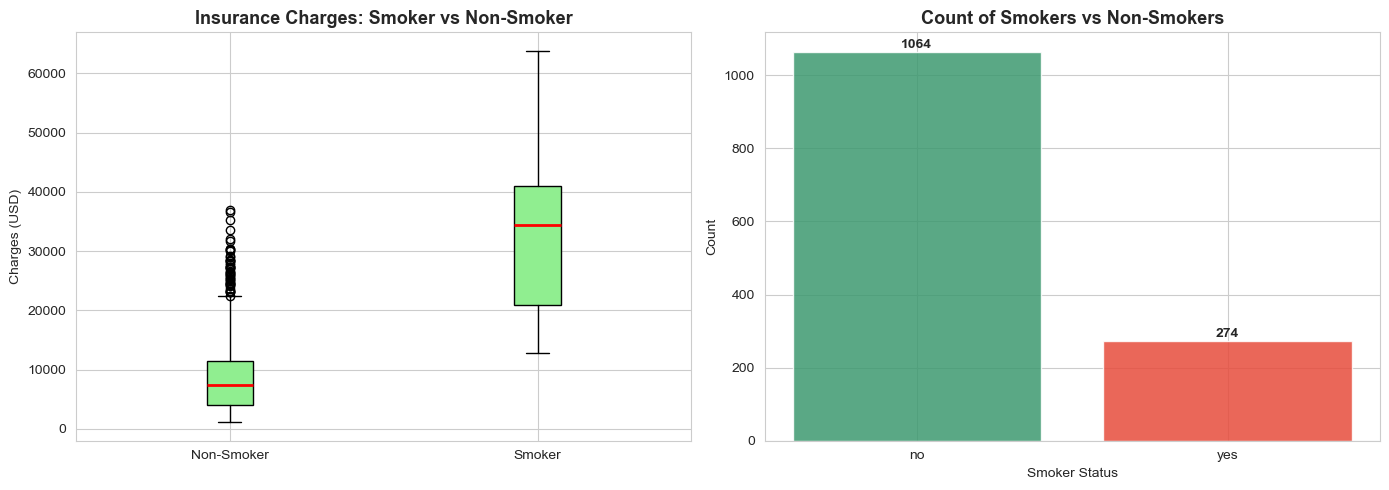

In [9]:
# 3.2 Charges by Smoker Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: smoker vs charges
smoker_yes = df[df['smoker'] == 'yes']['charges']
smoker_no = df[df['smoker'] == 'no']['charges']

axes[0].boxplot([smoker_no, smoker_yes], labels=['Non-Smoker', 'Smoker'],
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Insurance Charges: Smoker vs Non-Smoker', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Charges (USD)')

# Count plot
smoker_counts = df['smoker'].value_counts()
axes[1].bar(smoker_counts.index, smoker_counts.values, color=['#3d9970', '#e74c3c'], edgecolor='white', alpha=0.85)
axes[1].set_title('Count of Smokers vs Non-Smokers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Smoker Status')
axes[1].set_ylabel('Count')
for i, v in enumerate(smoker_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('smoker_charges.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Smokers pay dramatically higher insurance charges compared to non-smokers. This is one of the strongest signals in the dataset. Even though smokers are a minority (~20%), they incur significantly higher medical costs.

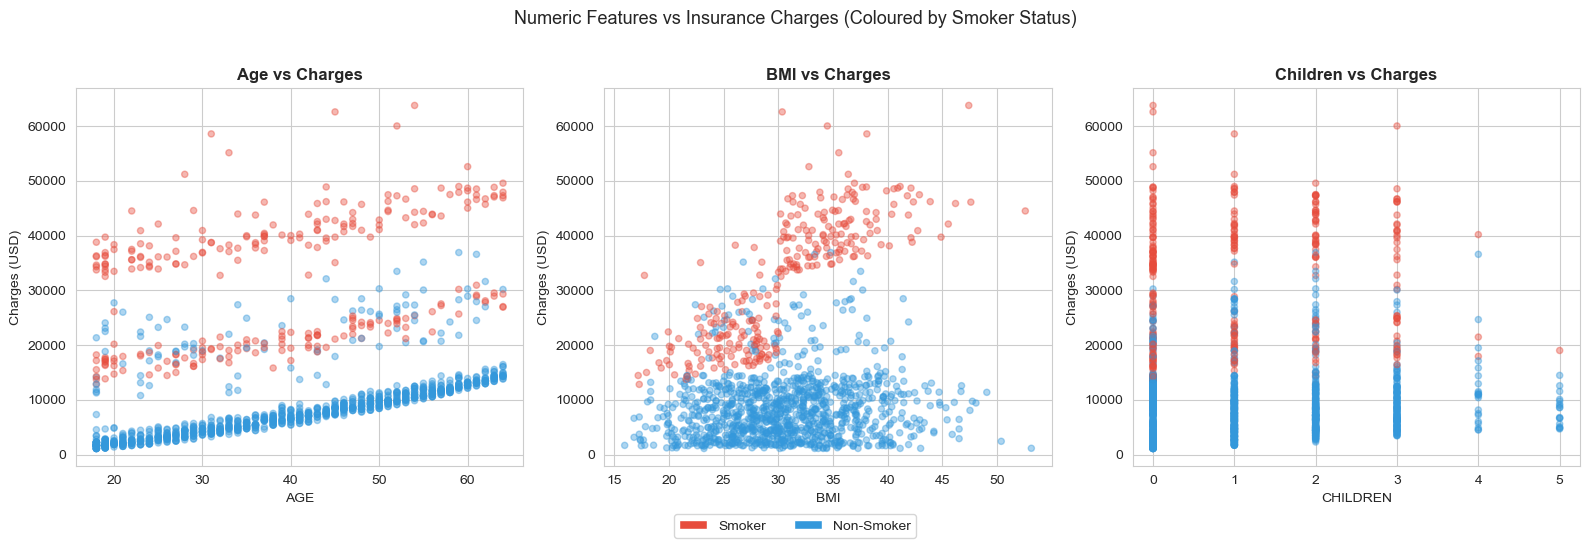

In [10]:
# 3.3 Scatter plots: Numeric features vs Charges
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'})

for ax, col, title in zip(axes,
                          ['age', 'bmi', 'children'],
                          ['Age vs Charges', 'BMI vs Charges', 'Children vs Charges']):
    ax.scatter(df[col], df['charges'], c=colors, alpha=0.4, s=20)
    ax.set_xlabel(col.upper())
    ax.set_ylabel('Charges (USD)')
    ax.set_title(title, fontweight='bold')

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Smoker'), Patch(facecolor='#3498db', label='Non-Smoker')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Numeric Features vs Insurance Charges (Coloured by Smoker Status)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

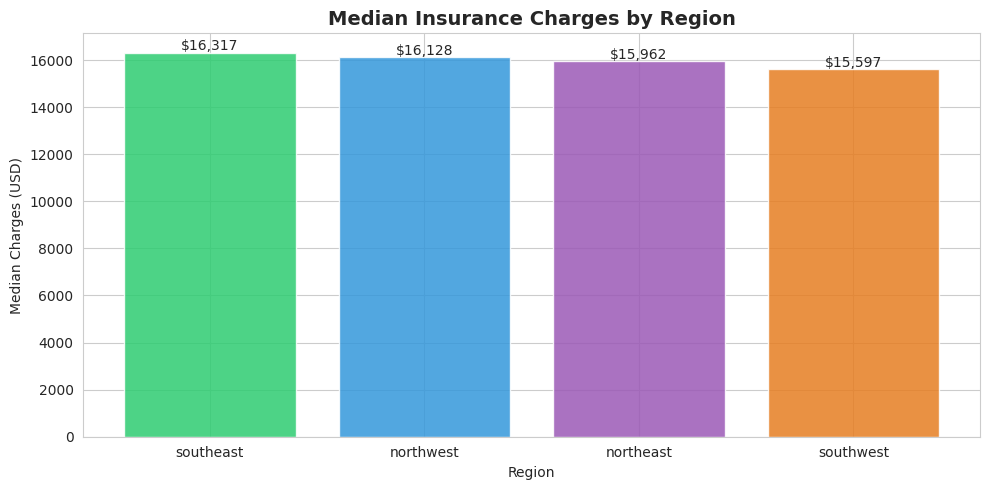

In [ ]:
# 3.4 Charges by Region
plt.figure(figsize=(10, 5))
region_order = df.groupby('region')['charges'].median().sort_values(ascending=False).index
region_medians = df.groupby('region')['charges'].median().sort_values(ascending=False)

bars = plt.bar(region_medians.index, region_medians.values,
               color=['#2ecc71', '#3498db', '#9b59b6', '#e67e22'], edgecolor='white', alpha=0.85)
plt.title('Median Insurance Charges by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Median Charges (USD)')
for bar, val in zip(bars, region_medians.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 100, f'${val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('region_charges.png', dpi=120, bbox_inches='tight')
plt.show()

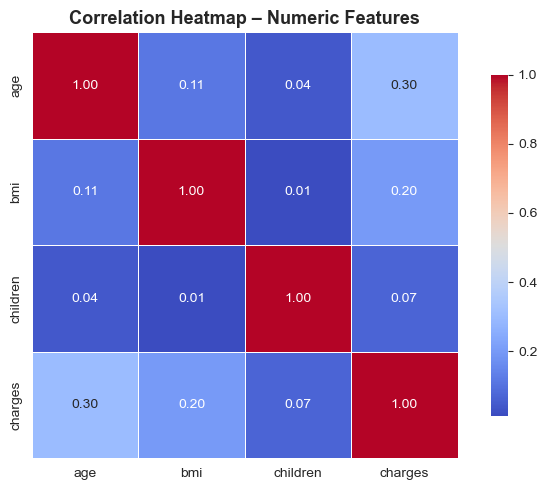

In [11]:
# 3.5 Correlation Heatmap (numeric features only)
numeric_df = df[['age', 'bmi', 'children', 'charges']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap – Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

###  EDA Summary – Key Findings

| Variable | Observation |
|----------|-------------|
| `smoker` | **Strongest predictor** – smokers pay significantly more than non-smokers |
| `age` | **Positive relationship** – older clients generally pay higher charges |
| `bmi` | **Moderate positive relationship** – higher BMI is associated with higher costs, especially for smokers |
| `children` | **Weak positive relationship** – more dependents slightly increases charges |
| `region` | **Minor differences** – region has a relatively small effect on charges |
| `sex` | **Minimal effect** – gender shows little variation in average charges |

---

## Task 4: Data Preprocessing

Machine learning algorithms require **numeric input**. Our dataset contains three categorical columns:
- `sex` – binary (`male` / `female`)
- `smoker` – binary (`yes` / `no`)
- `region` – multi-class with 4 categories

We will use **one-hot encoding** (dummy variables) to convert these into numeric format. This creates a new binary column for each category, which avoids creating a false ordinal ranking between categories.

We use `drop_first=True` to avoid the **dummy variable trap** (multicollinearity) — where one category can be perfectly predicted from the others.

In [12]:
# Task 4: Data Preprocessing – Convert categorical variables to numeric

# Create a copy so we preserve the original data
df_encoded = df.copy()

# Convert categorical variables into dummy variables
# drop_first=True avoids multicollinearity (dummy variable trap)
df_encoded = pd.get_dummies(df_encoded, columns=['sex', 'smoker', 'region'], drop_first=True)

# Convert boolean columns to integer (0/1) for clarity
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Encoded dataset shape:", df_encoded.shape)
print("\nColumn names after encoding:")
print(df_encoded.columns.tolist())
print("\nFirst 5 rows of encoded dataset:")
df_encoded.head()

Encoded dataset shape: (1338, 9)

Column names after encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

First 5 rows of encoded dataset:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


**Explanation of encoded columns:**
- `sex_male` → 1 if male, 0 if female
- `smoker_yes` → 1 if smoker, 0 if non-smoker
- `region_northwest`, `region_southeast`, `region_southwest` → binary flags for each region (northeast is the reference category)

---

## Task 5: Define Features and Target Variable

We separate the dataset into:
- **X** – the feature matrix (all columns except `charges`)
- **y** – the target vector (`charges` — what we want to predict)

In [13]:
# Task 5: Define Features (X) and Target Variable (y)

X = df_encoded.drop(columns=['charges'])  # Features
y = df_encoded['charges']                 # Target variable

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix X shape: (1338, 8)
Target vector y shape: (1338,)

Feature columns:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


---

## Task 6: Split Dataset into Training and Testing Sets

We split the data into:
- **Training set (80%)** – used to train (fit) the model
- **Testing set (20%)** – used to evaluate how well the model generalises to unseen data

We use `random_state=42` to ensure reproducibility — running the notebook again will produce the same split.

In [14]:
# Task 6: Split the Dataset (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set size:  ", X_train.shape[0], "records")
print("Testing set size:   ", X_test.shape[0], "records")
print(f"\nTraining proportion: {X_train.shape[0]/len(X)*100:.1f}%")
print(f"Testing proportion:  {X_test.shape[0]/len(X)*100:.1f}%")

Training set size:   1070 records
Testing set size:    268 records

Training proportion: 80.0%
Testing proportion:  20.0%


---

## Task 7: Train the Linear Regression Model

**Linear Regression** models the relationship between features and the target as a straight-line equation:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Where:
- $\hat{y}$ = predicted charges
- $\beta_0$ = intercept (baseline cost)
- $\beta_1, \beta_2, \ldots$ = coefficients showing the effect of each feature

The model finds the **best-fitting line** by minimising the sum of squared errors (Ordinary Least Squares method).

In [15]:
# Task 7: Train the Linear Regression Model

# Instantiate the model
lr_model = LinearRegression()

# Fit the model on the training data
lr_model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nIntercept (β₀): ${lr_model.intercept_:,.2f}")

print("\nFeature Coefficients:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

Model trained successfully!

Intercept (β₀): $-11,931.22

Feature Coefficients:
         Feature  Coefficient
      smoker_yes 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
        sex_male   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


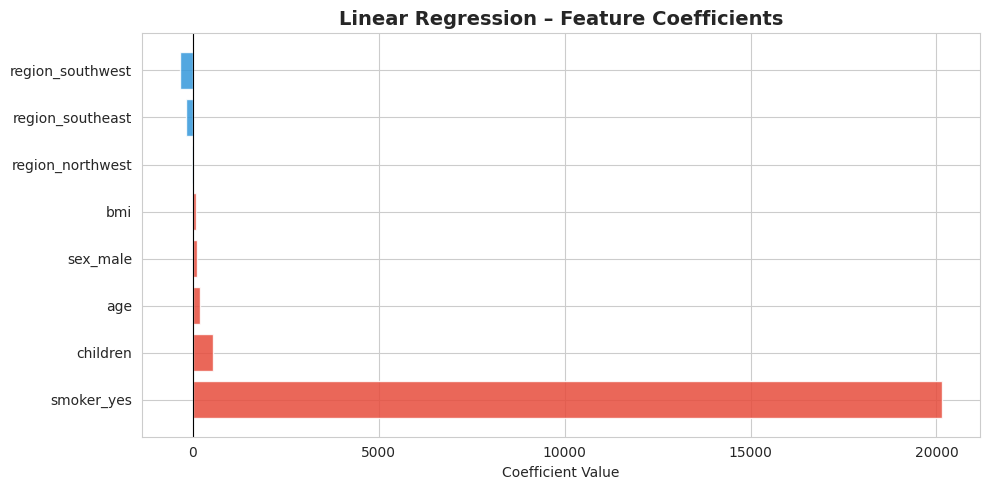

In [ ]:
# Visualise the coefficients
plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression – Feature Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation of Coefficients:**
- **`smoker_yes`** has by far the largest positive coefficient — being a smoker is predicted to increase charges by ~$20,000
- **`age`** has a positive coefficient — each additional year of age increases charges
- **`bmi`** has a positive coefficient — higher BMI is associated with higher costs
- **`children`** has a small positive effect
- **Regional and sex features** have relatively small coefficients

---

## Task 8: Make Predictions

Now we apply the trained model to the **test set** to generate predicted insurance charges. We then compare these predictions to the actual values.

In [16]:
# Task 8: Make Predictions on the Test Set

y_pred = lr_model.predict(X_test)

# Create a comparison DataFrame
results_df = pd.DataFrame({
    'Actual Charges':    y_test.values,
    'Predicted Charges': y_pred.round(2),
    'Difference':        (y_test.values - y_pred).round(2)
})

print("Sample predictions (first 10 records):")
print(results_df.head(10).to_string(index=False))

Sample predictions (first 10 records):
 Actual Charges  Predicted Charges  Difference
     9095.06825            8969.55      125.52
     5272.17580            7068.75    -1796.57
    29330.98315           36858.41    -7527.43
     9301.89355            9454.68     -152.78
    33750.29180           26973.17     6777.12
     4536.25900           10864.11    -6327.85
     2117.33885             170.28     1947.06
    14210.53595           16903.45    -2692.91
     3732.62510            1092.43     2640.19
    10264.44210           11218.34     -953.90


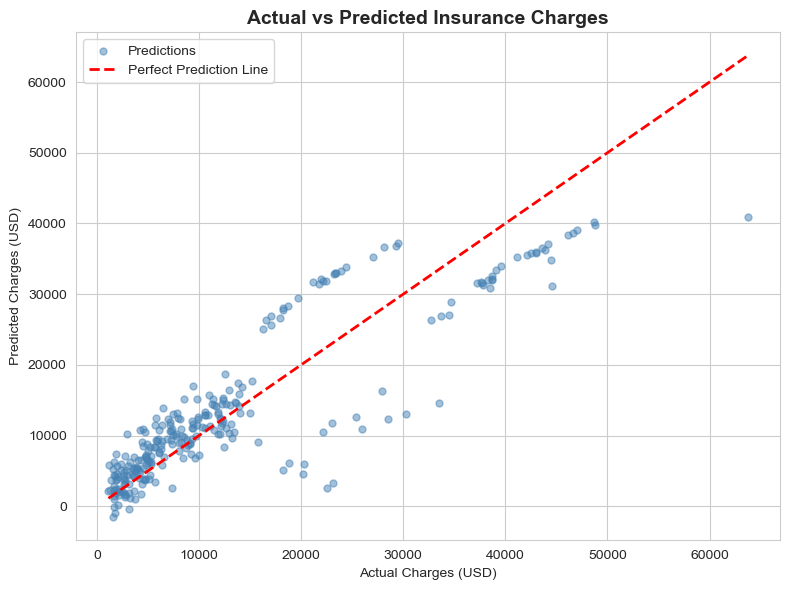

In [17]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=25, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.title('Actual vs Predicted Insurance Charges', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

---

## Task 9: Evaluate Model Performance

We evaluate the model using three standard regression metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute prediction error in USD |
| **RMSE** (Root Mean Squared Error) | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penalises large errors more heavily |
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained (0 to 1; higher is better) |

In [18]:
# Task 9: Evaluate Model Performance

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("       MODEL PERFORMANCE METRICS")
print("=" * 45)
print(f"  Mean Absolute Error  (MAE):  ${mae:>10,.2f}")
print(f"  Root Mean Sq. Error (RMSE):  ${rmse:>10,.2f}")
print(f"  R² Score:                    {r2:>10.4f}")
print("=" * 45)
print(f"\nThe model explains {r2*100:.1f}% of the variance in insurance charges.")

       MODEL PERFORMANCE METRICS
  Mean Absolute Error  (MAE):  $  4,181.19
  Root Mean Sq. Error (RMSE):  $  5,796.28
  R² Score:                        0.7836

The model explains 78.4% of the variance in insurance charges.


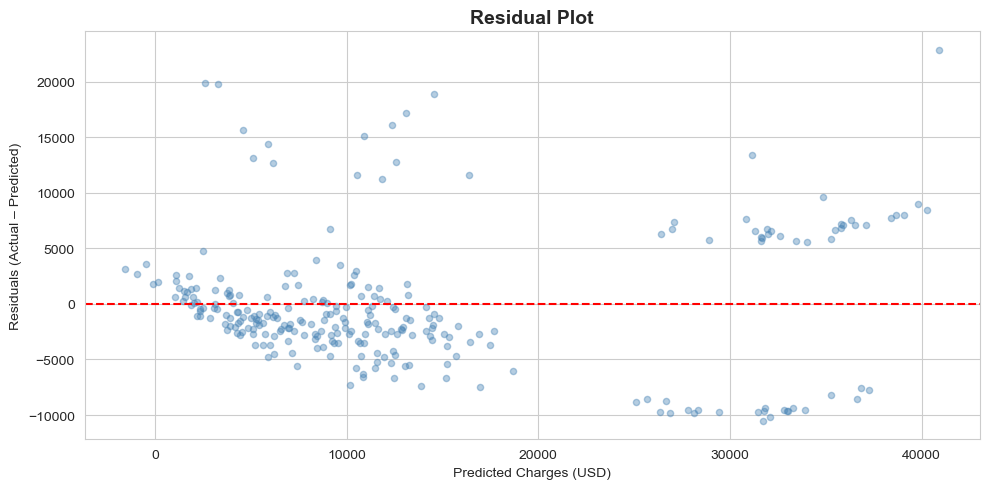

In [19]:
# Residual plot – check for systematic errors
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='steelblue', s=20)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Charges (USD)')
plt.ylabel('Residuals (Actual – Predicted)')
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation of Model Performance:**

- The **R² score** tells us how much of the variation in insurance charges is explained by our model. A value above 0.75 indicates a reasonably good fit.
- The **MAE** tells us the average dollar amount by which our predictions are off.
- The **residual plot** shows some fan-shaped spreading at higher predicted values, suggesting the model's errors are larger for high-cost clients. This is a typical pattern called **heteroscedasticity**, which can be addressed with data transformations.

---

## Task 10: Reflection

### 1. Which variables most strongly influence medical insurance charges?

Based on both the EDA and the model coefficients, the following variables are the **most important predictors** of medical insurance charges:

1. **`smoker`** — This is the single most powerful predictor. Smokers are charged dramatically more than non-smokers (often $15,000–$25,000 more per year). This aligns with the high coefficient observed in our model.
2. **`age`** — Older individuals consistently pay more. Healthcare costs naturally increase with age due to higher medical utilisation.
3. **`bmi`** — Higher BMI is associated with greater health risks (diabetes, cardiovascular disease), which drives up insurance costs — especially when combined with smoking.
4. **`children`** — Having more dependents slightly increases charges, as more individuals are covered under the policy.

---

### 2. Why might smoking affect insurance costs?

Smoking is a major health risk factor linked to a wide range of serious medical conditions, including:
- **Lung cancer** and other respiratory diseases
- **Cardiovascular disease** (heart attacks, strokes)
- **Chronic Obstructive Pulmonary Disease (COPD)**
- **Diabetes complications** and delayed wound healing

Because smokers have a statistically much higher likelihood of requiring expensive medical treatment, insurance companies charge higher premiums to offset this financial risk. Essentially, the premium reflects the **expected future cost** of insuring that individual.

---

### 3. What improvements could be made to the model?

Several improvements could enhance model accuracy:

| Improvement | Rationale |
|-------------|----------|
| **Log-transform `charges`** | The target variable is right-skewed; a log transformation can normalise it and improve linear model fit |
| **Add interaction terms** | E.g., `smoker × bmi` — smokers with high BMI may face non-linear cost increases |
| **Use polynomial features** | Non-linear relationships (e.g., age²) could be captured better |
| **Try Ridge or LASSO regression** | Regularisation methods can reduce overfitting and improve generalisation |
| **Try non-linear models** | Random Forest or Gradient Boosting may capture complex patterns that linear regression misses |
| **Feature engineering** | Creating meaningful combined features (e.g., BMI categories: underweight, normal, overweight, obese) |

---

